# Kwant — Theory and Practice · Chapter 10
## Z₂ and chiral superconductors — Kane–Mele and p+ip

*Part II · Sections 22–23 · Figures 53–58* &nbsp;·&nbsp; [← Chapter 9](09_Chern_Numbers.ipynb) · [Contents](00_Contents.ipynb) · [Chapter 11 →](11_Higher_Order_and_Weyl.ipynb)

### In this chapter

- [22. The Kane–Mele model — Z₂ and the quantum spin Hall effect](#22.-The-Kane–Mele-model-—-Z₂-and-the-quantum-spin-Hall-effect)
- [23. The p+ip superconductor — chiral Majorana edges](#23.-The-p+ip-superconductor-—-chiral-Majorana-edges)

Run the **Setup** cell first: it imports Kwant, reports the sparse solver, mutes three library warnings and defines `show_fig`, whose figure counter continues the course-wide numbering. Each chapter is self-contained given its Setup cell (a *carried over* cell, where present, rebuilds an object defined in an earlier chapter). Installation, the `kwant` kernel and the conventions are in [`00_Contents.ipynb`](00_Contents.ipynb).

`SPDX-License-Identifier: Apache-2.0` — Copyright 2026 Fabio Campolim.


In [1]:
# --- Setup: run this cell first ----------------------------------------------
# Imports, the sparse-solver report, three muted library warnings, and the
# figure helper.  Every chapter of the course starts with this cell.
import kwant
import numpy as np
import scipy
import tinyarray as ta                   # noqa: F401  (used by later cells)
import matplotlib
from matplotlib import pyplot

print("kwant", kwant.__version__, "| numpy", np.__version__,
      "| scipy", scipy.__version__, "| matplotlib", matplotlib.__version__)

# Which sparse solver is active? MUMPS is much faster than SciPy's SuperLU.
import kwant.solvers.default
print("default solver:", kwant.solvers.default.__name__)
try:
    import kwant.solvers.mumps          # noqa: F401
    print("MUMPS available: yes")
except ImportError:
    print("MUMPS available: no  (falling back to scipy sparse -> slower)")

matplotlib.rcParams['figure.figsize'] = (7, 5)

# Mute three library warnings that are not ours to fix and would otherwise be
# printed under some figures.  Done by wrapping warnings.showwarning rather than
# with warnings.filterwarnings(), because kwant.plotter calls
# warnings.resetwarnings() on every 3D plot, which silently deletes all user
# filters (reported upstream).  Only these three messages are muted:
#  * kwant 1.5.0's 3D plotter calls a matplotlib function deprecated in 3.10
#    (fixed on Kwant's main branch, unreleased);
#  * mpmath (via sympy) uses a deprecated bitcount helper;
#  * kwant.plotter.map notes that a few density values exceed the colour range,
#    which is expected for the delta-like densities in sections 6 and 12.
import warnings
_MUTED = ('proj_transform_clip', 'bitcount function is deprecated', 'overflowing upper limit')
_showwarning = warnings.showwarning

def _quiet_showwarning(message, category, filename, lineno, file=None, line=None):
    if not any(k in str(message) for k in _MUTED):
        _showwarning(message, category, filename, lineno, file, line)

warnings.showwarning = _quiet_showwarning

# --- Figure helper ------------------------------------------------------------
# Every figure ends with show_fig("..."), which stamps an auto-numbered italic
# caption under the figure and then shows it.  Figures are numbered
# continuously across the chapters of the course: this chapter's figures are
# 53–58, so the counter starts at 52.  (Re-running a single cell out of
# order advances it -- harmless, but numbers shift.)
_FIG_NO = [52]

def show_fig(caption=None):
    if caption:
        _FIG_NO[0] += 1
        fig = pyplot.gcf()
        fig.text(0.5, -0.02, f"Figure {_FIG_NO[0]}: {caption}",
                 ha='center', va='top', fontsize=9, style='italic',
                 wrap=True, transform=fig.transFigure)
    pyplot.show()


kwant 1.5.0 | numpy 2.5.1 | scipy 1.18.0 | matplotlib 3.10.7
default solver: kwant.solvers.default
MUMPS available: yes


In [2]:
# --- Carried over from section 20 -----------------------------------
# `chern_fhs`, the Fukui–Hatsugai–Suzuki Chern number of § 20.
# The code is the definition of section 20, verbatim.
import kwant, numpy as np
from matplotlib import pyplot

def chern_fhs(hfunc, n_occ, n1=40, n2=40):
    """Chern number by the Fukui-Hatsugai-Suzuki plaquette method.

    hfunc(x1, x2): Bloch Hamiltonian, 2pi-periodic in both arguments.  The
    result is exactly integer on any grid fine enough to resolve the gap.
    (Reused by every 2D section below.)
    """
    xs1 = np.linspace(0, 2 * np.pi, n1, endpoint=False)
    xs2 = np.linspace(0, 2 * np.pi, n2, endpoint=False)
    frames = np.empty((n1, n2), dtype=object)
    for i, x1 in enumerate(xs1):
        for j, x2 in enumerate(xs2):
            frames[i, j] = np.linalg.eigh(hfunc(x1, x2))[1][:, :n_occ]
    link = lambda a, b: np.linalg.det(a.conj().T @ b)
    F = 0.0
    for i in range(n1):
        for j in range(n2):
            u1 = link(frames[i, j], frames[(i+1) % n1, j])
            u2 = link(frames[(i+1) % n1, j], frames[(i+1) % n1, (j+1) % n2])
            u3 = link(frames[(i+1) % n1, (j+1) % n2], frames[i, (j+1) % n2])
            u4 = link(frames[i, (j+1) % n2], frames[i, j])
            F += np.angle(u1 * u2 * u3 * u4)
    return int(round(F / (2 * np.pi)))

print('chern_fhs', 'ready')


chern_fhs ready


In [3]:
# --- Carried over from section 21 -----------------------------------
# `bloch_hamiltonian`, the wraparound Bloch Hamiltonian of § 21.
# The code is the definition of section 21, verbatim.
import kwant, kwant.wraparound, numpy as np
from matplotlib import pyplot

def bloch_hamiltonian(bulk_builder, prim_vecs):
    """H(theta1, theta2), theta_i = phase across primitive vector i.

    Works for any 2D lattice: wraparound gives H(k) in Cartesian momenta;
    mapping through the reciprocal vectors makes it 2pi-periodic in theta,
    which is what chern_fhs (section 20) expects.
    """
    wrapped = kwant.wraparound.wraparound(bulk_builder).finalized()
    b1, b2 = 2 * np.pi * np.linalg.inv(np.array(prim_vecs)).T
    def hfunc(th1, th2):
        k = (th1 * b1 + th2 * b2) / (2 * np.pi)
        return wrapped.hamiltonian_submatrix(params=dict(k_x=k[0], k_y=k[1]))
    return hfunc

print('bloch_hamiltonian', 'ready')


bloch_hamiltonian ready


---
## 22. The Kane–Mele model — Z₂ and the quantum spin Hall effect

Kane & Mele [PRL **95**, 226801 (2005)] asked what intrinsic spin–orbit
coupling does to graphene.  The answer founded the field of topological
insulators: each spin sector is a Haldane model, with opposite chirality for
opposite spins (so time reversal is preserved),

$$H = t\!\!\sum_{\langle ij\rangle}\! c_i^\dagger c_j
 + i\lambda_{SO}\!\!\sum_{\langle\langle ij\rangle\rangle}\!\! \nu_{ij}\,
   c_i^\dagger \sigma_z c_j .$$

With $S_z$ conserved the spin Chern numbers are $C_\uparrow = -C_\downarrow =
1$: total Chern number zero, but a $\mathbb{Z}_2$ invariant
$\nu = (C_\uparrow - C_\downarrow)/2 \bmod 2 = 1$.  The edges carry a
**helical** Kramers pair (opposite spins move in opposite directions), giving
$G = 2e^2/h$.

The deep point is what survives when $S_z$ conservation is broken (Rashba
term $i\lambda_R (\boldsymbol{\sigma}\times\mathbf{d})_z$ on NN bonds): the
spin Chern numbers lose meaning, but time reversal still forbids
backscattering between Kramers partners — the edge crossing and the quantized
conductance persist.  That robustness *is* the $\mathbb{Z}_2$ classification.
A staggered potential $M > 3\sqrt{3}\lambda_{SO}$ kills the phase.

**Physics in more depth.**  In graphene itself the intrinsic SOC gap is
microscopic ($\sim\mu$eV; Yao *et al.*, PRB **75**, 041401 (2007)), which is
why the quantum spin Hall effect was first seen in HgTe quantum wells
[König *et al.*, Science **318**, 766 (2007), following the BHZ prediction
in §13].  The honeycomb route was later vindicated by heavy-element
analogues: bismuthene on SiC with a 0.8 eV gap [Reis *et al.*, Science
**357**, 287 (2017)] — and monolayer WTe₂ [Wu *et al.*, Science **359**, 76 (2018)].
The $\mathbb{Z}_2$ classification itself: Kane & Mele, PRL **95**, 146802
(2005).


C_up = +1,  C_dn = -1,  C_total = 0   =>   Z2 = 1


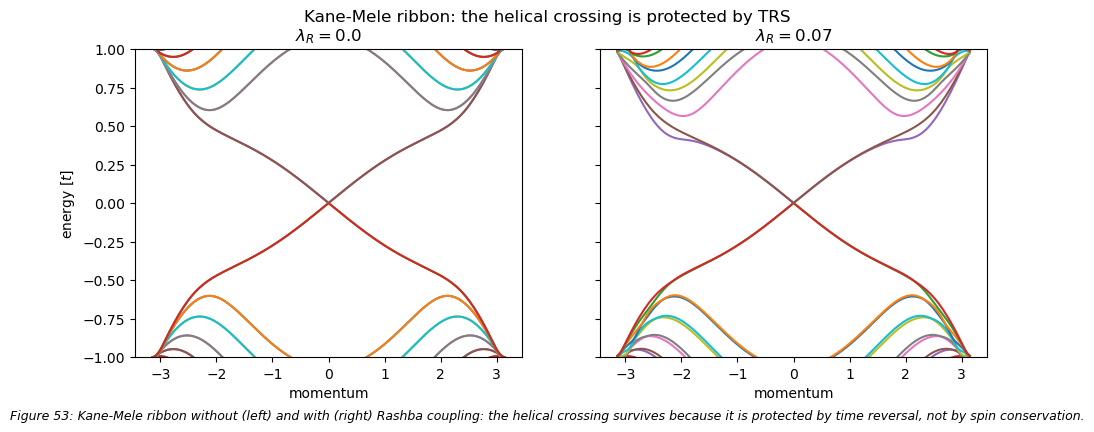

clean                 :  T = 2.00000
disorder U0=0.4       :  T = 1.99993


disorder + Rashba     :  T = 1.99994
M > Mc (trivial)      :  T = 0.00000


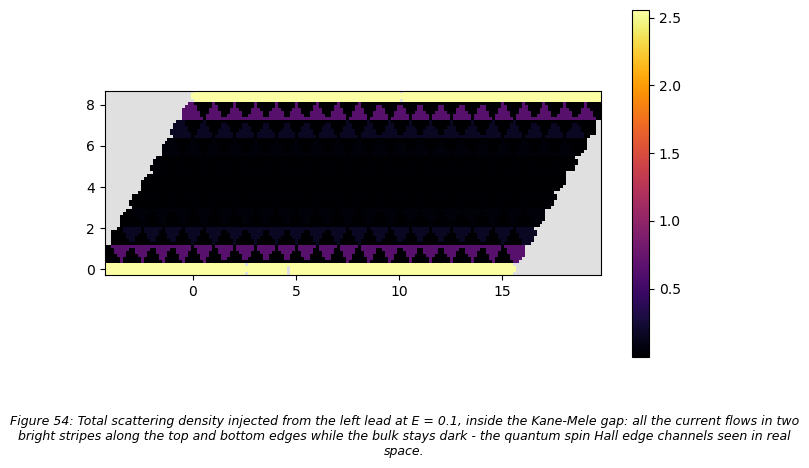

In [4]:
# --- Kane-Mele: spin Chern numbers, helical edges, quantized G ----------------
import kwant, kwant.wraparound, numpy as np
from matplotlib import pyplot

s0 = np.eye(2)
sx = np.array([[0, 1], [1, 0]])
sy = np.array([[0, -1j], [1j, 0]])
sz = np.array([[1, 0], [0, -1]])

t1_km, lam_so = 1.0, 0.1
lat = kwant.lattice.honeycomb(norbs=2)              # 2 orbitals = spin
a_sub, b_sub = lat.sublattices
nnn_a = [kwant.builder.HoppingKind(v, a_sub, a_sub)
         for v in [(1, 0), (-1, 1), (0, -1)]]
nnn_b = [kwant.builder.HoppingKind(v, b_sub, b_sub)
         for v in [(1, 0), (-1, 1), (0, -1)]]

def rashba_nn(lam_r):
    def val(s1, s2):
        d = s1.pos - s2.pos
        return t1_km * s0 + 1j * lam_r * (sx * d[1] - sy * d[0])
    return val

def km_system(sym=None, M=0.0, lam_r=0.0, U0=0.0, shape=None, salt="km"):
    syst = kwant.Builder(sym) if sym is not None else kwant.Builder()
    def onsite(s):
        m = M if s.family == a_sub else -M
        dis = U0 * (kwant.digest.uniform(repr(s.tag) + s.family.name, salt) - .5)
        return (m + dis) * s0
    if shape is None:                       # translationally invariant bulk
        syst[a_sub(0, 0)] = M * s0
        syst[b_sub(0, 0)] = -M * s0
    else:
        syst[lat.shape(shape, (0, 0))] = onsite
    syst[lat.neighbors()] = rashba_nn(lam_r)
    for kind in nnn_a:
        syst[kind] = 1j * lam_so * sz       # spin-up: one chirality...
    for kind in nnn_b:
        syst[kind] = -1j * lam_so * sz      # ...spin-down: the opposite one
    return syst

# spin-resolved Chern numbers (basis per cell: A-up, A-dn, B-up, B-dn)
h_full = bloch_hamiltonian(
    km_system(kwant.TranslationalSymmetry(*lat.prim_vecs)), lat.prim_vecs)
spin_idx = {'up': np.array([0, 2]), 'dn': np.array([1, 3])}
spin_block = lambda h, s: (
    lambda t1, t2: h(t1, t2)[np.ix_(spin_idx[s], spin_idx[s])])

C_up = chern_fhs(spin_block(h_full, 'up'), n_occ=1, n1=24, n2=24)
C_dn = chern_fhs(spin_block(h_full, 'dn'), n_occ=1, n1=24, n2=24)
C_tot = chern_fhs(h_full, n_occ=2, n1=24, n2=24)
print(f"C_up = {C_up:+d},  C_dn = {C_dn:+d},  C_total = {C_tot}"
      f"   =>   Z2 = {abs(C_up - C_dn) // 2 % 2}")
assert C_up == -C_dn and C_tot == 0

# helical edge states: the crossing survives a Rashba perturbation
ribbon_shape = lambda p: 0 <= p[1] < 12 * np.sqrt(3) / 2
fig, axes = pyplot.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, lam_r in zip(axes, (0.0, 0.07)):
    frib = km_system(kwant.TranslationalSymmetry(lat.vec((1, 0))),
                     lam_r=lam_r, shape=ribbon_shape).finalized()
    kwant.plotter.bands(frib, momenta=np.linspace(-np.pi, np.pi, 161), ax=ax)
    ax.set_ylim(-1, 1); ax.set_title(f"$\\lambda_R = {lam_r}$")
    ax.set_xlabel("momentum")
axes[0].set_ylabel("energy $[t]$")
fig.suptitle("Kane-Mele ribbon: the helical crossing is protected by TRS")
show_fig(r'Kane-Mele ribbon without (left) and with (right) Rashba coupling: the helical crossing survives because it is protected by time reversal, not by spin conservation.')

# transport: G = 2 e^2/h, robust to TRS-preserving disorder and Rashba
def km_bar(M=0.0, lam_r=0.0, U0=0.0, W=10, L=16):
    shape = lambda p: (0 <= p[0] < L) and (0 <= p[1] < W * np.sqrt(3) / 2)
    syst = km_system(M=M, lam_r=lam_r, U0=U0, shape=shape)
    syst.eradicate_dangling()
    lead = km_system(kwant.TranslationalSymmetry(lat.vec((1, 0))), M=M,
                     lam_r=lam_r, shape=lambda p: 0 <= p[1] < W * np.sqrt(3) / 2)
    syst.attach_lead(lead)
    syst.attach_lead(lead.reversed())
    return syst.finalized()

E = 0.1
for kwargs, label in [(dict(), "clean"),
                      (dict(U0=0.4), "disorder U0=0.4"),
                      (dict(U0=0.4, lam_r=0.05), "disorder + Rashba"),
                      (dict(M=1.5 * 3 * np.sqrt(3) * lam_so), "M > Mc (trivial)")]:
    T = kwant.smatrix(km_bar(**kwargs), E).transmission(1, 0)
    print(f"{label:22s}:  T = {T:.5f}")

# the helical edge channels in real space
fkm = km_bar()
psi_km = kwant.wave_function(fkm, E)(0)
rho_km = kwant.operator.Density(fkm)
d_km = sum(rho_km(p) for p in psi_km)
kwant.plotter.map(fkm, d_km, oversampling=4, cmap='inferno',
                  fig_size=(8, 4.5), show=False)
show_fig(r'Total scattering density injected from the left lead at E = 0.1, inside the Kane-Mele gap: all the current flows in two bright stripes along the top and bottom edges while the bulk stays dark - the quantum spin Hall edge channels seen in real space.')

---
## 23. The p+ip superconductor — chiral Majorana edges

Read & Green [PRB **61**, 10267 (2000)]: a 2D spinless superconductor with
$p_x + ip_y$ pairing,

$$H(\mathbf{k}) = \left[-2t(\cos k_x + \cos k_y) - \mu\right]\tau_z
 + \Delta\left(\sin k_x\, \tau_x + \sin k_y\, \tau_y\right),$$

is the 2D relative of the Kitaev chain: same symmetry class (D), but in 2D the
invariant is the **Chern number of the BdG bands**.  The weak-pairing phases
$-4t < \mu < 0$ and $0 < \mu < 4t$ carry $C = \pm 1$; strong pairing
($|\mu| > 4t$) is trivial.

Bulk–boundary correspondence here produces something strictly stranger than in
a Chern insulator: the edge carries a single **chiral Majorana mode** — "half"
a chiral fermion, $\gamma(-E)=\gamma^\dagger(E)$ — and a vortex in the order
parameter binds a Majorana zero mode, which is the original proposal for
topological quantum computation.  Below: the BdG Chern number through both
transitions, the chiral Majorana dispersion on a strip, and its localization
on the boundary of a finite sample.

**Physics in more depth.**  Beyond the chiral edge, the bulk of a p+ip
superconductor holds its most famous property: a vortex binds a single
Majorana zero mode, and vortices consequently obey **non-abelian
statistics** [Read & Green, PRB **61**, 10267 (2000); Ivanov, PRL **86**,
268 (2001)].  Intrinsic p-wave materials are scarce — the long-standing
Sr₂RuO₄ candidacy is now heavily qualified [Mackenzie *et al.*, npj Quantum
Mater. **2**, 40 (2017)] — so the modern route is *engineering*: the surface
of a 3D TI proximitised by an s-wave superconductor behaves exactly like
p+ip without breaking time reversal [Fu & Kane, PRL **100**, 096407
(2008)].  Review of topological superconductivity: Sato & Ando, Rep. Prog.
Phys. **80**, 076501 (2017).


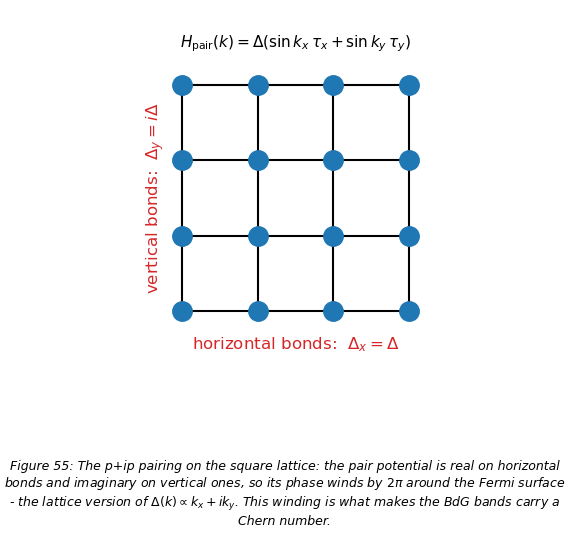

In [5]:
# --- geometry: the p+ip pairing pattern --------------------------------------
import numpy as np
from matplotlib import pyplot

fig, ax = pyplot.subplots(figsize=(5.5, 5))
for i in range(4):
    for j in range(4):
        if i < 3:
            ax.plot([i, i + 1], [j, j], 'k-', lw=1.5)
        if j < 3:
            ax.plot([i, i], [j, j + 1], 'k-', lw=1.5)
        ax.plot(i, j, 'o', color='C0', ms=14, zorder=3)
ax.text(1.5, -0.5, r'horizontal bonds:  $\Delta_x = \Delta$', ha='center',
        fontsize=12, color='C3')
ax.text(-0.5, 1.5, r'vertical bonds:  $\Delta_y = i\Delta$', va='center',
        rotation=90, fontsize=12, color='C3')
ax.text(1.5, 3.5,
        r'$H_{\rm pair}(k) = \Delta(\sin k_x\,\tau_x + \sin k_y\,\tau_y)$',
        ha='center', fontsize=11)
ax.set_xlim(-1.1, 4)
ax.set_ylim(-1.1, 4)
ax.set_aspect('equal')
ax.set_axis_off()
show_fig(r'The p+ip pairing on the square lattice: the pair potential is real on horizontal bonds and imaginary on vertical ones, so its phase winds by $2\pi$ around the Fermi surface - the lattice version of $\Delta(k)\propto k_x + i k_y$. This winding is what makes the BdG bands carry a Chern number.')

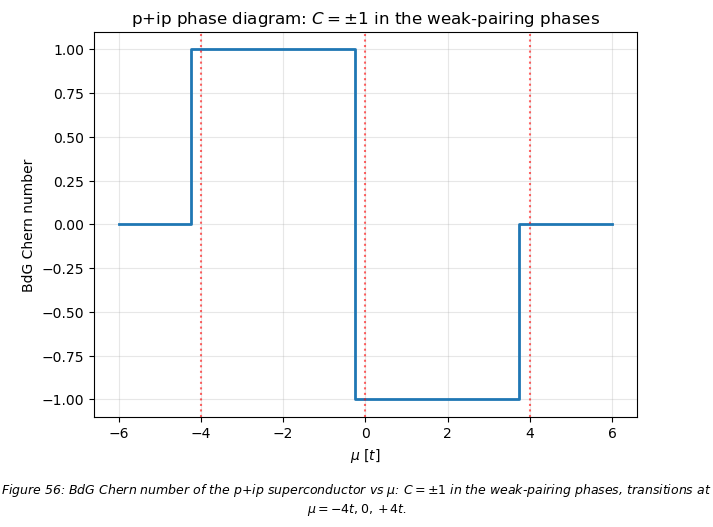

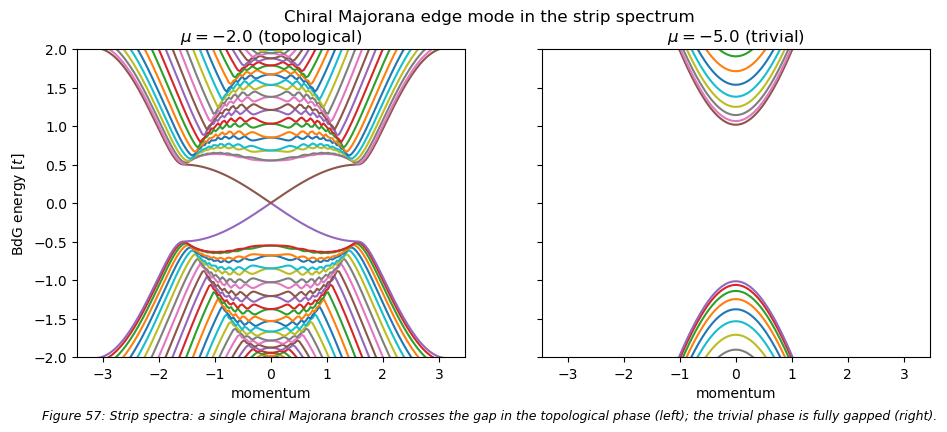

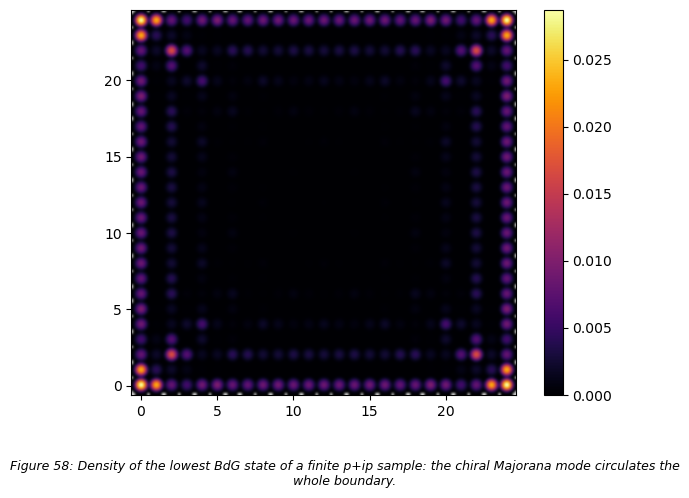

lowest BdG level |E| = 0.0138 (a +/-E particle-hole pair); the density map shows the chiral Majorana circulating the boundary


In [6]:
# --- p+ip: BdG Chern number, chiral Majorana edge mode ------------------------
import kwant, kwant.wraparound, numpy as np
import scipy.sparse.linalg as sla
from matplotlib import pyplot

tau_x = np.array([[0, 1], [1, 0]])
tau_y = np.array([[0, -1j], [1j, 0]])
tau_z = np.array([[1, 0], [0, -1]])
t, Delta = 1.0, 0.5
lat = kwant.lattice.square(norbs=2)             # Nambu (particle, hole)

hop_x = -t * tau_z - 0.5j * Delta * tau_x
hop_y = -t * tau_z - 0.5j * Delta * tau_y

def pip_bulk(mu):
    syst = kwant.Builder(kwant.TranslationalSymmetry(*lat.prim_vecs))
    syst[lat(0, 0)] = -mu * tau_z
    syst[kwant.builder.HoppingKind((1, 0), lat, lat)] = hop_x
    syst[kwant.builder.HoppingKind((0, 1), lat, lat)] = hop_y
    return syst

# BdG Chern number vs mu: transitions at mu = -4t, 0, +4t
mus = np.linspace(-6, 6, 25)
Cs = [chern_fhs(bloch_hamiltonian(pip_bulk(m), lat.prim_vecs),
                n_occ=1, n1=20, n2=20) for m in mus]
pyplot.step(mus, Cs, where='mid', lw=2)
for m in (-4, 0, 4):
    pyplot.axvline(m, color='r', ls=':', alpha=.6)
pyplot.xlabel(r"$\mu\ [t]$"); pyplot.ylabel("BdG Chern number")
pyplot.title(r"p+ip phase diagram: $C=\pm1$ in the weak-pairing phases")
pyplot.grid(alpha=.3); show_fig(r'BdG Chern number of the p+ip superconductor vs $\mu$: $C=\pm1$ in the weak-pairing phases, transitions at $\mu=-4t,0,+4t$.')

# strip: the chiral Majorana branch crosses E = 0
def pip_strip(mu, W=25):
    syst = kwant.Builder(kwant.TranslationalSymmetry((-1, 0)))
    syst[(lat(0, y) for y in range(W))] = -mu * tau_z
    syst[kwant.builder.HoppingKind((1, 0), lat, lat)] = hop_x
    syst[kwant.builder.HoppingKind((0, 1), lat, lat)] = hop_y
    return syst.finalized()

fig, axes = pyplot.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, mu, label in zip(axes, (-2.0, -5.0), ("topological", "trivial")):
    kwant.plotter.bands(pip_strip(mu), momenta=np.linspace(-np.pi, np.pi, 161),
                        ax=ax)
    ax.set_ylim(-2, 2); ax.set_title(f"$\\mu = {mu}$ ({label})")
    ax.set_xlabel("momentum")
axes[0].set_ylabel("BdG energy $[t]$")
fig.suptitle("Chiral Majorana edge mode in the strip spectrum")
show_fig(r'Strip spectra: a single chiral Majorana branch crosses the gap in the topological phase (left); the trivial phase is fully gapped (right).')

# the near-zero mode of a finite sample lives on the boundary
W = L = 25
syst = kwant.Builder()
syst[(lat(x, y) for x in range(L) for y in range(W))] = 2.0 * tau_z  # mu = -2
syst[kwant.builder.HoppingKind((1, 0), lat, lat)] = hop_x
syst[kwant.builder.HoppingKind((0, 1), lat, lat)] = hop_y
fsyst = syst.finalized()
ham = fsyst.hamiltonian_submatrix(sparse=True).tocsc()
ev, vec = sla.eigsh(ham, k=8, sigma=0)
i0 = np.argmin(np.abs(ev))
dens = (np.abs(vec[:, i0]) ** 2).reshape(-1, 2).sum(axis=1)
kwant.plotter.density(fsyst, dens, cmap='inferno', show=False)
show_fig(r'Density of the lowest BdG state of a finite p+ip sample: the chiral Majorana mode circulates the whole boundary.')
print(f"lowest BdG level |E| = {abs(ev[i0]):.4f} (a +/-E particle-hole pair); the density map shows the "
      "chiral Majorana circulating the boundary")